# Reconstruction using API

When you have multiple scans, you might want to automate a workflow. 
Instead of opening your scans one by one inside the GUI, you can also use 
`openalea.plantgl` functions in combination with `openalea.plantscan3d` api.


All the steps for reconstruction are available in the [reconstruction](reconstruction.rst) page.

> **📝 Note**
> `openalea.plantscan3d` is a GUI-first tool for editing point cloud and perform reconstruction. 
> Right now, the API is not as complete and fully-featured as the GUI. It is here to help user 
> that need to perform batch treatment or perform a quick reconstruction. Please raise an issue 
> on the official [github repository](https://github.com/openalea/plantscan3d/issues) if you need more features.

We first import the necessary `openalea.plantscan3d` and `openalea.plantgl` dependencies 
that will be used in the reconstruction and visualization.

In [1]:
import glob
import os
from pathlib import Path

from importlib.resources import files, as_file
from openalea.plantscan3d.api.processmtg import (
    determine_radius, generate_mtg, trunk_lateral_axes, 
    trunk_direction, trunk_radii, trunk_length, 
    trunk_branching_zone_start, trunk_branching_zone_end, trunk_branching_zone_length,
    axis_length, axis_chord_length, axis_subpart_angle, axis_extremities_angle,
    retrieve_axis_radii
)
from openalea.plantscan3d.api.processpoints import filter_points, load_points, skeleton, subsample
from openalea.plantscan3d.api.visualization import view, view_points, mtg_to_scene, nodemtg_to_scene, points_to_scene
from openalea.plantscan3d.mtgmanip import gaussian_filter, pipemodel
from openalea.plantscan3d.serial import writeMTGfile, convertToStdMTG, writefile
from openalea.plantscan3d.xumethod import xu_method
from openalea.plantscan3d.livnymethod import livny_method_mtg

from openalea.plantgl.all import Scene, contract_point3
from openalea.plantscan3d.mtgmanip import gaussian_filter

## Load the point cloud

You can now load any point cloud and visualize quickly the points distribution.

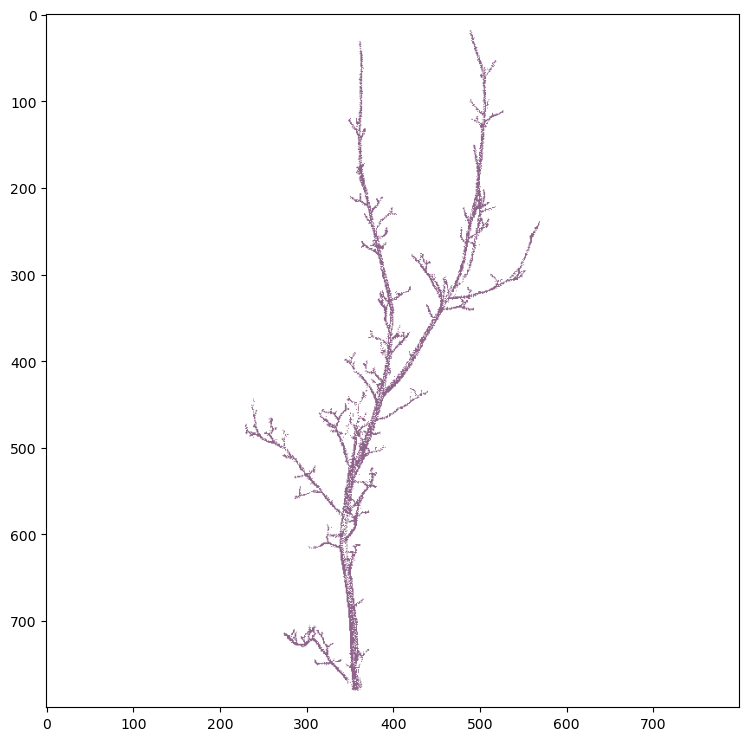

In [2]:
datadir = files('openalea.plantscan3d.data.scans_example')
points = load_points(str(datadir / 'A3B4.asc'))
view_points(points)

## Points filtering and contraction

We can now perform the filtering / contraction and display the result.

Nb points processed 10000 (100.00%) [left : 0 (0.00%)].
Density computed for 75.80% of points.oints.

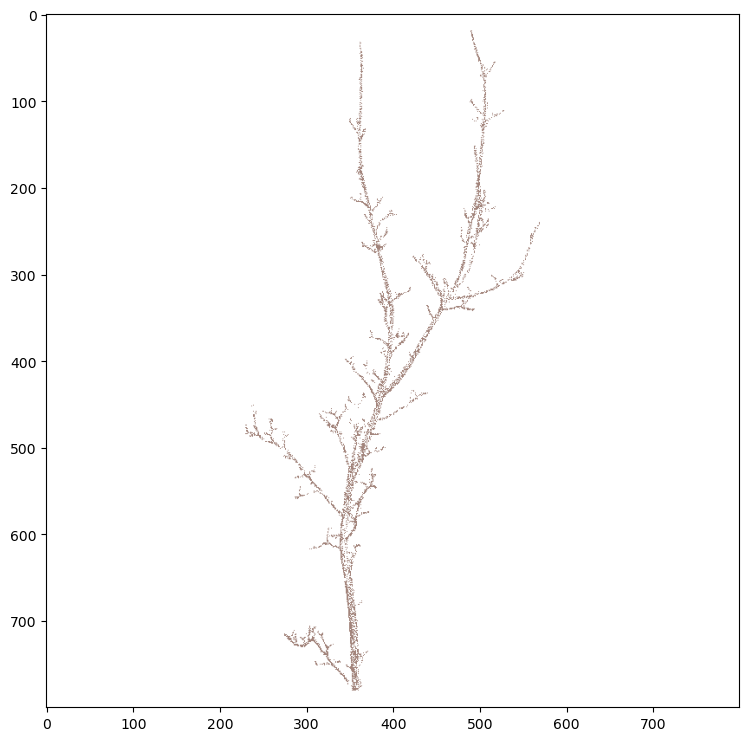

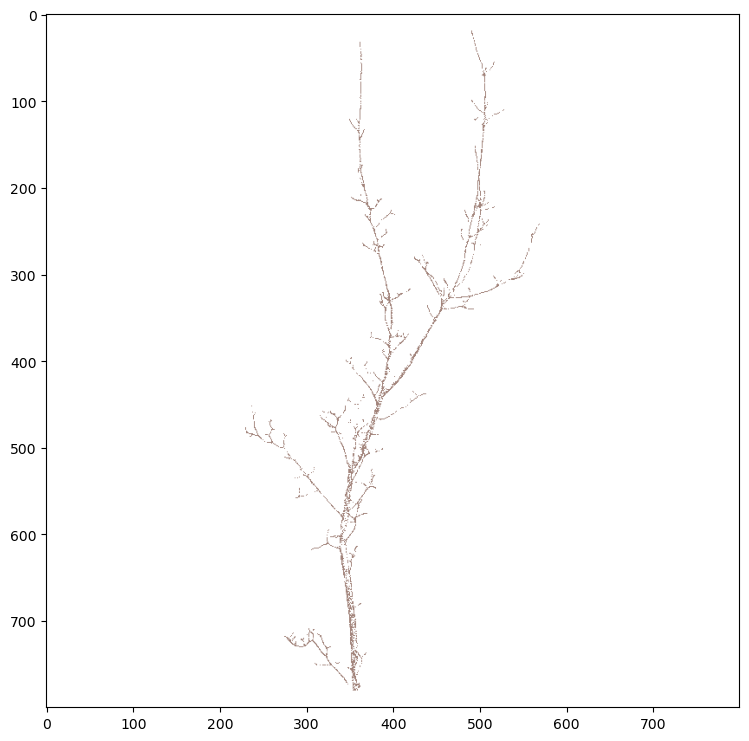

In [3]:
# If you want to subsample the points
points = subsample(points, 10000)
points = filter_points(points)
view_points(points)

# You can also perform point contraction
cpoints = contract_point3(points, 0.03)
view_points(cpoints)

## Topology reconstruction

We can do topology reconstruction, using different algorithms. 
Please check the [api documentation](../api.rst) for input parameters to the skeleton function.

Generate point color : 100.00%Compute Remanian graph.
Connect all components of Riemanian graph.
Nb points processed 9940 (100.00%) [left : 0 (0.00%)].
Compute distance to root.
Compute cluster according to distance to root.
Nb of groups : 256
Compute adjacency graph of groups.
Compute centroid of groups.
Compute spanning tree of groups.
Remove short nodes  


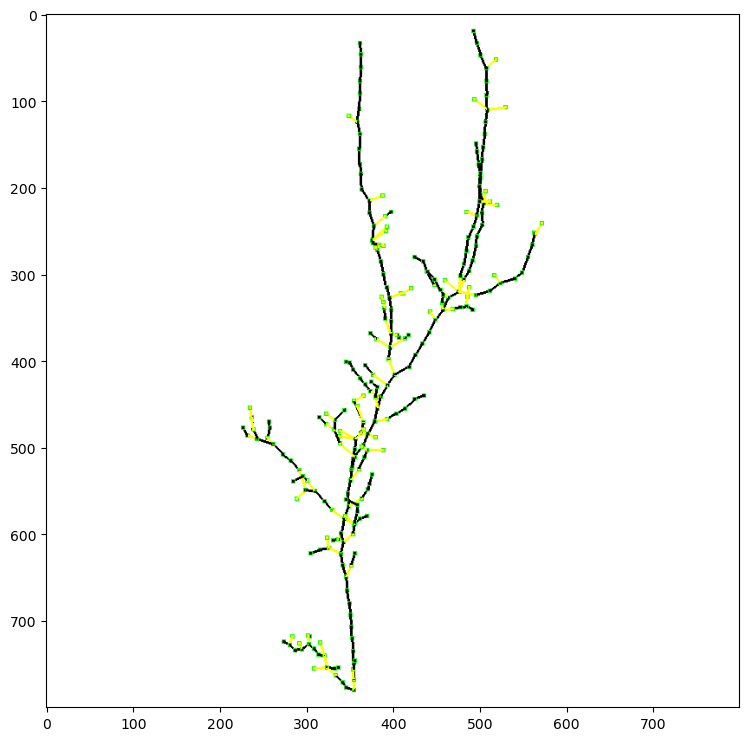

average distance to points : 0.0065998880482173875
compute radii
edge length characterization
Filter nodes 0.01929525742635105
Percentage short node filtered : 77.71629778672032 ( 7725 )
Filtering : pass 1
similar nodes detected : 62
Nb of merges : 62
Percentage filtered : 4.153498871331829
recompute weights
average distance to points : 0.012031867368749893
recompute radii
Filtering : pass 2
similar nodes detected : 38
Nb of merges : 38
Percentage filtered : 1.9783325482807348
recompute weights
average distance to points : 0.012093055439949537
recompute radii
Filtering : pass 3
similar nodes detected : 8
Nb of merges : 8
Percentage filtered : 0.38443056222969724
recompute weights
average distance to points : 0.01208401529804684
recompute radii
Filtering : pass 4
Nb points processed 9105 (91.60%) [left : 835 (8.40%)].
Nb points processed 9819 (98.78%) [left : 121 (1.22%)].
Nb points processed 9827 (98.86%) [left : 113 (1.14%)].
Nb points processed 9870 (99.30%) [left : 70 (0.70%)].
Nb p

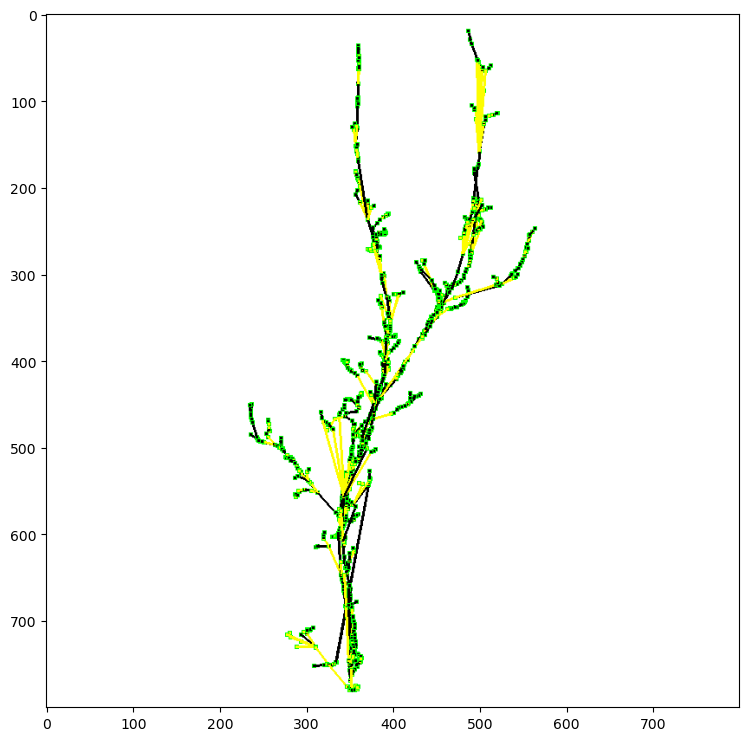

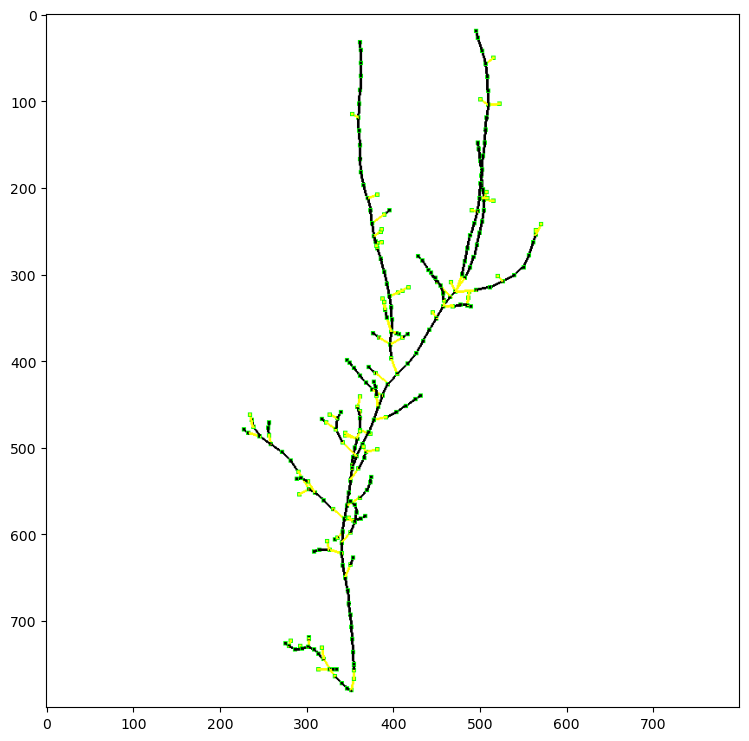

In [4]:
# Xu reconstruction method
binratio = 50
k = 20
mtg_xu = skeleton(points, skel_func=xu_method, xu_binratio=binratio, xu_neighbors=k)
view(nodemtg_to_scene(mtg_xu))

# Liivny reconstruction method
nb_contraction = 3
nb_filtering = 5
min_edge_ration = 0.15
mtg_livny = skeleton(points, skel_func=livny_method_mtg, livny_contraction_nb=nb_contraction, livny_filtering_nb=nb_filtering, livny_min_edge_ratio=min_edge_ration)
view(nodemtg_to_scene(mtg_livny))

# You can smooth the positions
gaussian_filter(mtg_xu, "position")
view(nodemtg_to_scene(mtg_xu))

And finally we determine the radius property of the MTG.

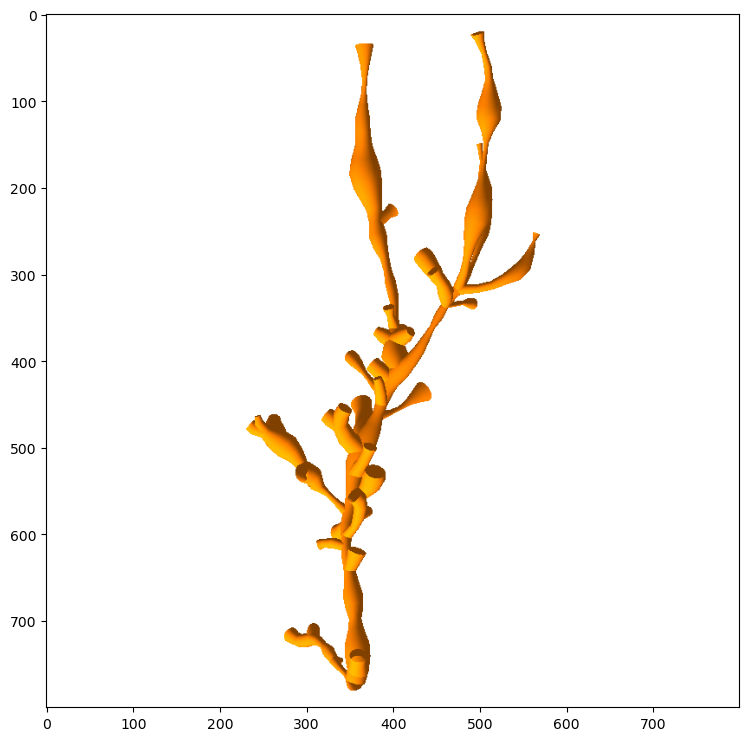

In [5]:
determine_radius(mtg_xu, points)
# You can also smooth the radius
gaussian_filter(mtg_xu, "radius", False)
view(mtg_to_scene(mtg_xu))

This doesn't look so good. We'll apply the pipe model to obtain a more realistic estimation of the radius.

2 257
0.8298985480706467


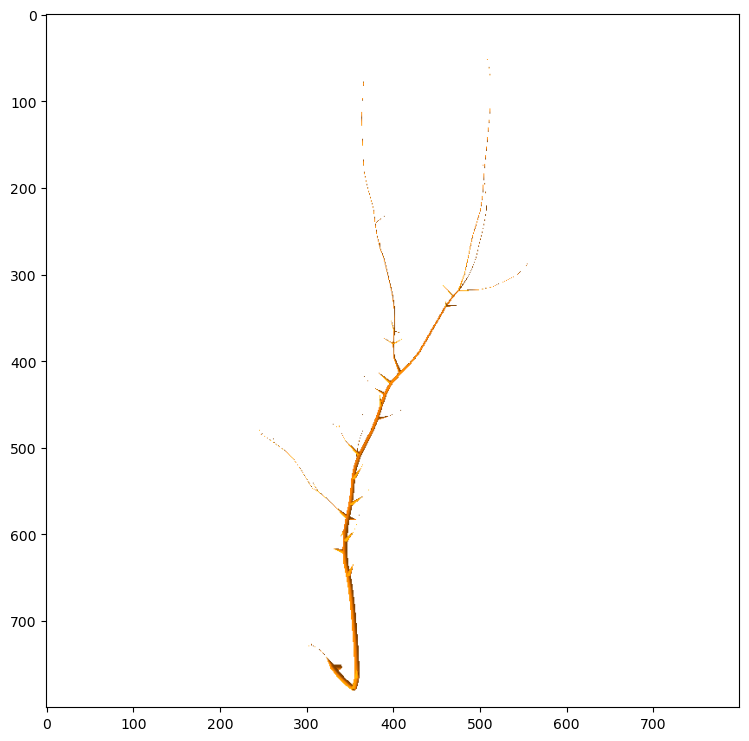

In [6]:
from openalea.plantscan3d.mtgmanip import pipemodel, get_first_param_value
# We need to define "root" and "leaf" radii for the pipe model
# Here we define "root" as the first node, but you can also set the id of any node
pipemodel_radii = pipemodel(mtg_xu)
mtg_xu.property("radius").update(pipemodel_radii)
view(mtg_to_scene(mtg_xu))

## Save reconstructed MTG

In [7]:
writeMTGfile("A3B4_reconstructed_xu.mtg", convertToStdMTG(mtg_xu))

## Automatic processing of the scans

We can now do some automatic processing and analyses of multiple scans. 
Here we detail the implementation of the {py:func}`openalea.plantscan3d.api.processmtg.characterize_mtg`:

In [8]:
def characterize_mtg(g):
    # Get the lists of short and long lateral axes.
    shortaxis, longaxis = trunk_lateral_axes(g)
    # Determine the trunk direction.
    trunk_dir = trunk_direction(g, 0.5)
    # Determine the trunk radius at the base and the at top.
    trunkbaseradius, trunktopradius = trunk_radii(g, 0.1, 0.1)
    
    res = dict(
        # Determine the length of the trunk.
        trunk_length = trunk_length(g),
        # Determine the start of the trunk branching zone.
        trunk_branching_zone_start = trunk_branching_zone_start(g),
        # Determine the end of the trunk branching zone.
        trunk_branching_zone_end = trunk_branching_zone_end(g),
        # Determine the length of the trunk's branching zone.
        trunk_branching_zone_length = trunk_branching_zone_length(g),
        trunk_base_radius = trunkbaseradius,
        trunk_top_radius = trunktopradius,
        nb_short_axis = len(shortaxis),
        nb_long_axis = len(longaxis),
    )
    
    bot_angle_param = 0, 0.15
    top_angle_param = 0.85, 1
    
    # Determine the length of each long axis.
    res.update([('axis1_length_'+str(i),axis_length(g,l)) for i,l in enumerate(longaxis)])
    # Determine the chord length of each long axis.
    res.update([('axis1_chord_length_'+str(i),axis_chord_length(g,l)) for i,l in enumerate(longaxis)])
    # Determine the angle between the trunk and the bottom of each long axis.
    res.update([('axis1_angle_bot_'+str(i),axis_subpart_angle(g, l, bot_angle_param[0], bot_angle_param[1], trunk_dir)) for i,l in enumerate(longaxis)])
    # Determine the angle between the trunk and the top of each long axis.
    res.update([('axis1_angle_top_'+str(i),axis_subpart_angle(g, l, top_angle_param[0], top_angle_param[1], trunk_dir)) for i,l in enumerate(longaxis)])
    # Determine the angle between the trunk and the extremities of each long axis.
    res.update([('axis1_extremities_angle_'+str(i),axis_extremities_angle(g, l, trunk_dir)) for i,l in enumerate(longaxis)])
    for i,l in enumerate(longaxis):
        rfirst, rmedian, rlast = retrieve_axis_radii(g,l)
        # Determine the radius of the first node of the axis.
        res['axis1_rfirst_'+str(i)] = rfirst
        # Determine the radius of the last node of the axis.
        res['axis1_rlast_'+str(i)] = rlast
        # Determine the mean value of the radius of the axis.
        res['axis1_rmedian_'+str(i)] = rmedian
    return res

And we handle multiple scans at the same time:

In [9]:
def aggregate_df(dfs):
    import pandas as pd
    # Check if we have at least one dataframe
    assert len(dfs) > 0
    props = set(dfs[0][1].keys())
    for v in dfs:
        props |= set(v[1].keys())
    resagg = dict(name= [v[0] for v in dfs])
    for propname in props:
        resagg[propname] = [v[1].get(propname) for v in dfs]
    df = pd.DataFrame.from_dict(resagg)
    return df

def process_all(filenames):
    # check number of txt files to process
    assert len(filenames) > 0
    res = []
    for filename in filenames:
        print ('process',filename)
        mtg = generate_mtg(filename, subsample={"ptsnb":10000})
        mtgfile = os.path.splitext(filename)[0]+'.bmtg'
        writefile(mtgfile,mtg)
        res.append((os.path.basename(filename), characterize_mtg(mtg)))
    df = aggregate_df(res)
    df = df[sorted(df.columns.values)]
    df.to_csv('results.csv')
    return df

In [10]:
datadir = files('openalea.plantscan3d.data.pointset')
with as_file(datadir) as p:
    filenames = glob.glob(os.path.join(Path(p),'puu*.bgeom'))
    print(filenames)
    df = process_all(filenames)
print(df)

['/var/folders/v1/6y176c8d2jz06qr8rd3jq_480000gn/T/tmpgqs4_e8c/pointset/puu1.bgeom', '/var/folders/v1/6y176c8d2jz06qr8rd3jq_480000gn/T/tmpgqs4_e8c/pointset/puu3.bgeom']
process /var/folders/v1/6y176c8d2jz06qr8rd3jq_480000gn/T/tmpgqs4_e8c/pointset/puu1.bgeom
Nb points processed 10000 (100.00%) [left : 0 (0.00%)].
Density computed for 100.00% of points.Compute Remanian graph.
Connect all components of Riemanian graph.
Nb points processed 5839 (100.00%) [left : 0 (0.00%)].
Compute distance to root.
Compute cluster according to distance to root.
Nb of groups : 564
Compute adjacency graph of groups.
Compute centroid of groups.
Compute spanning tree of groups.
Remove short nodes  
2 565
0.7267313922415436
process /var/folders/v1/6y176c8d2jz06qr8rd3jq_480000gn/T/tmpgqs4_e8c/pointset/puu3.bgeom
Nb points processed 10000 (100.00%) [left : 0 (0.00%)].
Density computed for 100.00% of points.Compute Remanian graph.
Connect all components of Riemanian graph.
Nb points processed 9021 (100.00%) [left